# Solução para o problema da mochila usando algoritmos genéticos

In [1505]:
import random
import copy
import pandas as pd

In [1506]:

NOME =  ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J"]
MASSA =  [2, 3, 4, 5, 7, 1, 6, 4.5, 3.5, 2.5]
VALOR =  [40, 50, 65, 80, 110, 15, 90, 70, 60, 55]

CAPACIDADE = 15

## Criando a população inicial

Representação dos cromossomos:

cada cromossomo é um vetor binário v, len(v) = 9.

v[i] = 0 indica a ausência do item de indíce i na mochila, enquanto v[i] = 1 indica a presença de tal item.

In [1507]:
populacao = []

while(len(populacao) < 50):
    idv = []
    
    for i in range(10):
        idv.append(random.randint(0, 1)) # gera individuos aleatoriamente

    
    peso_idv = 0
    
    # verifica se o individuo é factivel
    for i in range(10):
        if(idv[i] == 1):
            peso_idv += MASSA[i]
    
    # se é factível, adiciona à população
    if(peso_idv <= CAPACIDADE):
        populacao.append(idv)


## Funções importantes para a execução do algoritmo:

In [1508]:
def verifica_factivel(individuo: list) -> int: # retorna 0 se individuo não é factível, 1 se é factível

    peso_idv = 0

    for i in range(10):
        if(individuo[i] == 1):
            peso_idv += MASSA[i]
        
    if(peso_idv <= CAPACIDADE):
        
        return 1

    return 0 

In [1509]:
def calcula_fo(individuo: list) -> int: # retorna o valor da funcao objetivo para cada individuo
    
    valor = 0
    
    for i in range(10):
        if(individuo[i] == 1):
            valor += VALOR[i]

    return valor * verifica_factivel(individuo)    

In [1510]:
def selecao(populacao: list, numero_cruzamento: int) -> list: # retorna os indices dos selecionados para o cruzamento no vetor de populacao
    
    tam = len(populacao)
    idx = [i for i in range(tam)] # índices dos indivíduos

    # calcula a probabilidade de cada item ser selecionado baseado na sua funcao objetivo
    probabilidade = [0] * tam
    selecionados = [0] * numero_cruzamento

    soma_fos = 0
    for i in range(tam):
        soma_fos += calcula_fo(populacao[i])
    
    for i in range(tam):
        probabilidade[i] = (calcula_fo(populacao[i]) / soma_fos) * 100 

    # controle de individuos disponíveis pra selecao
    disponiveis = idx.copy()
    prob_disponiveis = probabilidade.copy()

    for i in range(numero_cruzamento):

        par = []

        for _ in range(2):
            if sum(prob_disponiveis) == 0:
                escolhido = random.choice(disponiveis)
            else:
                escolhido = random.choices(disponiveis, weights=prob_disponiveis)[0]
            
            par.append(escolhido)

            # remove o escolhido de disponiveis
            idx_remover = disponiveis.index(escolhido)
            disponiveis.pop(idx_remover)
            prob_disponiveis.pop(idx_remover)

        selecionados[i] = par

    return selecionados



In [1511]:
def mutacao(filhos: list) -> list:

    val = [0, 1]
    chances = [95, 5]

    ocorre = random.choices(val, weights = chances)[0] # 0 se não ocorre mutação, 1 se ocorre

    if (ocorre == 0): return filhos # não houve mutação

    while(True):

        f = random.randint(0, 1) # escolhe aleatoriamente o filho pra mutacao

        gen = random.randint(0, 9) # escolhe o gen que vai ser mudado

        mutante = copy.deepcopy(filhos[f])
        mutante[gen] = (int) (not mutante[gen]) # inverte o gene especificado

        if(verifica_factivel(mutante) == 1):

            filhos[f] = mutante

            return filhos

In [1512]:
def gera_nova_populacao(populacao: list, selecionados: list) -> list: # retorna a população com os indivíduos gerados a partir do cruzamento
    
    populacao_temp = populacao.copy()
    novos_individuos = []

    for par in selecionados:
        
        filhos = []

        while(len(filhos) < 2):

            num_genes = random.randint(1, 2) # crossover em 1 ou 2 genes
            

            for _ in range(num_genes):

                ######  crossover ######

                # escolhe aleatoriamente os indices dos genes a serem trocado
                gen1 = random.randint(0,9) 
                gen2 = random.randint(0,9)

                # inicia os filhos como copias dos pais
                filho1 = copy.deepcopy(populacao[par[0]])
                filho2 = copy.deepcopy(populacao[par[1]])

                # faz a troca dos genes
                temp = filho1[gen1]
                filho1[gen1] = filho2[gen2]
                filho2[gen2] = temp
 
                ######    fim     ######

                # verifica se filhos são factíveis
                if(len(filhos) < 2 and verifica_factivel(filho1) == 1): filhos.append(filho1)
                if(len(filhos) < 2 and verifica_factivel(filho2) == 1): filhos.append(filho2)
        

        filhos = mutacao(filhos) # 5% de chance de ocorrer mutação

        novos_individuos.extend(filhos)
    
    # nova populacao sem os pais e com os novos individuos
    nova_populacao = []

    indices_pais = set(i for par in selecionados for i in par)

    for idx, idv in enumerate(populacao_temp):

        if(idx not in indices_pais):

            nova_populacao.append(idv) # se não é pai, adiciona na nova população
    
    nova_populacao.extend(novos_individuos) # adiciona novos indivíduos a nova população

    return nova_populacao

In [1513]:
def acha_best(populacao: list) -> int:

    best = 0

    for idv in populacao:

        best = max(best, calcula_fo(idv))
    
    return best

## Resolução do problema:

In [ ]:
geracoes = 200

best = 0

# vetores para visualização:

best_vec = []

for i in range(geracoes):
    
    num_cruz = int (len(populacao) * 0.8/2)

    selecionados = selecao(populacao, num_cruz)

    populacao = gera_nova_populacao(populacao, selecionados)

    best = max(best, acha_best(populacao))

    best_vec.append(best)

    # print(f"geração: {i} -> best = {best} #### num_cruz = {num_cruz} #### tam populacao = {len(populacao)}")

geração: 0 -> best = 260 #### num_cruz = 20 #### tam populacao = 50
geração: 1 -> best = 260 #### num_cruz = 20 #### tam populacao = 50
geração: 2 -> best = 265 #### num_cruz = 20 #### tam populacao = 50
geração: 3 -> best = 265 #### num_cruz = 20 #### tam populacao = 50
geração: 4 -> best = 265 #### num_cruz = 20 #### tam populacao = 50
geração: 5 -> best = 265 #### num_cruz = 20 #### tam populacao = 50
geração: 6 -> best = 265 #### num_cruz = 20 #### tam populacao = 50
geração: 7 -> best = 265 #### num_cruz = 20 #### tam populacao = 50
geração: 8 -> best = 265 #### num_cruz = 20 #### tam populacao = 50
geração: 9 -> best = 265 #### num_cruz = 20 #### tam populacao = 50
geração: 10 -> best = 265 #### num_cruz = 20 #### tam populacao = 50
geração: 11 -> best = 265 #### num_cruz = 20 #### tam populacao = 50
geração: 12 -> best = 265 #### num_cruz = 20 #### tam populacao = 50
geração: 13 -> best = 265 #### num_cruz = 20 #### tam populacao = 50
geração: 14 -> best = 265 #### num_cruz = 20

<Axes: >

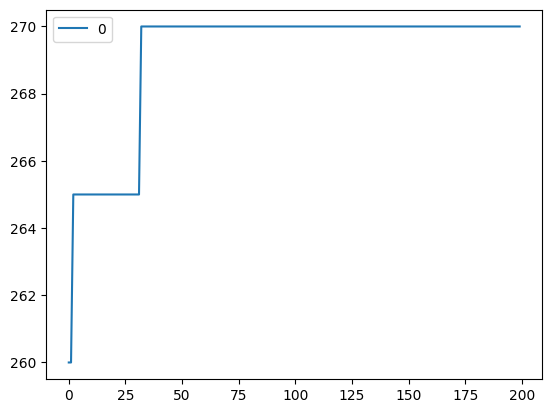

In [1515]:
df = pd.DataFrame(best_vec)

df.plot()